<a href="https://colab.research.google.com/github/bittokjeff/Machine-Learning/blob/main/data_mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

1. DATA ACQUISITION & SIMULATION

In [ ]:
# Simulating a high-dimensional Customer Churn dataset (1000 customers, 10 metrics)
X, y = make_classification(
    n_samples=1000, n_features=10, n_informative=7, n_redundant=3, random_state=42
)
feature_names = [f"metric_{i}" for i in range(1, 11)]
df = pd.DataFrame(X, columns=feature_names)
df['churned'] = y

In [ ]:
print(feature_names)

['metric_1', 'metric_2', 'metric_3', 'metric_4', 'metric_5', 'metric_6', 'metric_7', 'metric_8', 'metric_9', 'metric_10']


In [ ]:
df

,metric_1,metric_2,metric_3,metric_4,metric_5,metric_6,metric_7,metric_8,metric_9,metric_10,churned
0,-2.515984,-0.762055,-1.986676,4.148052,3.108808,6.324078,5.291429,-0.872057,1.183773,-0.805333,0
1,-0.672914,-1.563503,3.562810,0.396128,0.026731,-0.253737,3.483474,1.574252,-1.471795,0.698445,1
2,-1.953326,0.274618,0.050664,0.426035,1.272515,2.301115,1.280757,0.026285,-0.635284,1.614816,0
3,0.577318,-0.972563,0.355441,1.245819,-0.472508,-2.046506,-0.987116,0.734642,1.531011,-0.672260,1
4,-0.365302,-2.023199,0.731872,2.766902,-1.028713,-0.767302,-1.052613,-1.424615,2.164966,0.707496,1
...,...,...,...,...,...,...,...,...,...,...,...
995,1.468427,-0.715038,0.113270,-1.615633,0.476429,-1.802245,-2.027444,0.008016,-1.288974,2.388088,1
996,-0.137439,-0.901439,4.049779,-0.866080,-1.424819,-1.731930,2.718359,0.697166,-1.937974,2.316727,1
997,-2.499700,-0.709184,-4.605198,4.631038,3.802144,5.500652,0.085153,-1.794406,2.978009,0.615732,0
998,0.388159,-0.883744,3.308085,0.045588,-0.946480,-4.646834,1.058724,3.045642,0.004581,1.770809,0


In [ ]:
df.head()

,metric_1,metric_2,metric_3,metric_4,metric_5,metric_6,metric_7,metric_8,metric_9,metric_10,churned
0,-2.515984,-0.762055,-1.986676,4.148052,3.108808,6.324078,5.291429,-0.872057,1.183773,-0.805333,0
1,-0.672914,-1.563503,3.562810,0.396128,0.026731,-0.253737,3.483474,1.574252,-1.471795,0.698445,1
2,-1.953326,0.274618,0.050664,0.426035,1.272515,2.301115,1.280757,0.026285,-0.635284,1.614816,0
3,0.577318,-0.972563,0.355441,1.245819,-0.472508,-2.046506,-0.987116,0.734642,1.531011,-0.672260,1
4,-0.365302,-2.023199,0.731872,2.766902,-1.028713,-0.767302,-1.052613,-1.424615,2.164966,0.707496,1


In [ ]:
df.tail()

,metric_1,metric_2,metric_3,metric_4,metric_5,metric_6,metric_7,metric_8,metric_9,metric_10,churned
995,1.468427,-0.715038,0.113270,-1.615633,0.476429,-1.802245,-2.027444,0.008016,-1.288974,2.388088,1
996,-0.137439,-0.901439,4.049779,-0.866080,-1.424819,-1.731930,2.718359,0.697166,-1.937974,2.316727,1
997,-2.499700,-0.709184,-4.605198,4.631038,3.802144,5.500652,0.085153,-1.794406,2.978009,0.615732,0
998,0.388159,-0.883744,3.308085,0.045588,-0.946480,-4.646834,1.058724,3.045642,0.004581,1.770809,0
999,-2.774703,-2.262001,2.728152,4.450899,-1.905616,-0.125525,-0.546519,-0.426243,3.289359,-1.238552,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   metric_1   1000 non-null   float64
 1   metric_2   1000 non-null   float64
 2   metric_3   1000 non-null   float64
 3   metric_4   1000 non-null   float64
 4   metric_5   1000 non-null   float64
 5   metric_6   1000 non-null   float64
 6   metric_7   1000 non-null   float64
 7   metric_8   1000 non-null   float64
 8   metric_9   1000 non-null   float64
 9   metric_10  1000 non-null   float64
 10  churned    1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


In [ ]:
df.shape

(1000, 11)

In [ ]:
df.columns

Index(['metric_1', 'metric_2', 'metric_3', 'metric_4', 'metric_5', 'metric_6',
       'metric_7', 'metric_8', 'metric_9', 'metric_10', 'churned'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
metric_1,0
metric_2,0
metric_3,0
metric_4,0
metric_5,0
metric_6,0
metric_7,0
metric_8,0
metric_9,0
metric_10,0


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
995,False
996,False
997,False
998,False


Data Visualization

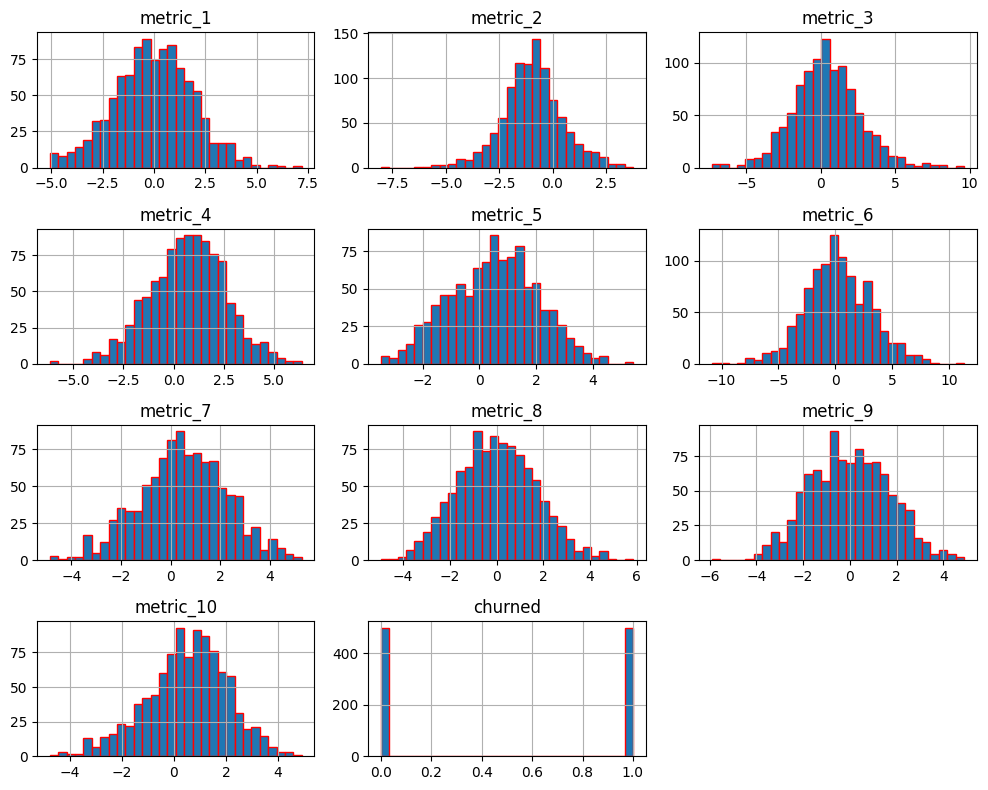

In [ ]:
df.hist(figsize=(10,8),bins=30,edgecolor='r')
plt.tight_layout()
plt.show()

<Axes: >

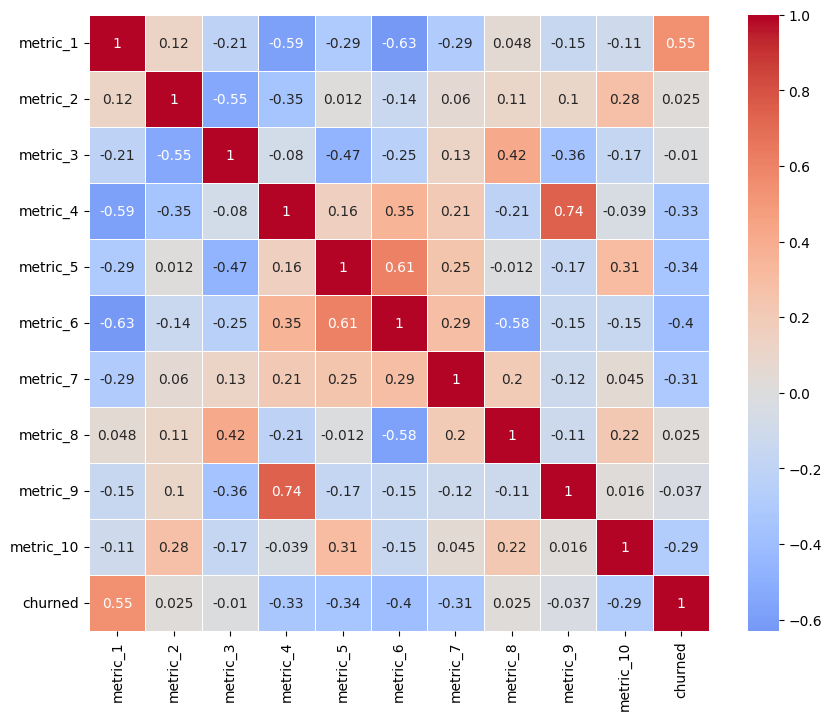

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,center=0,linewidth=0.5,cmap='coolwarm')

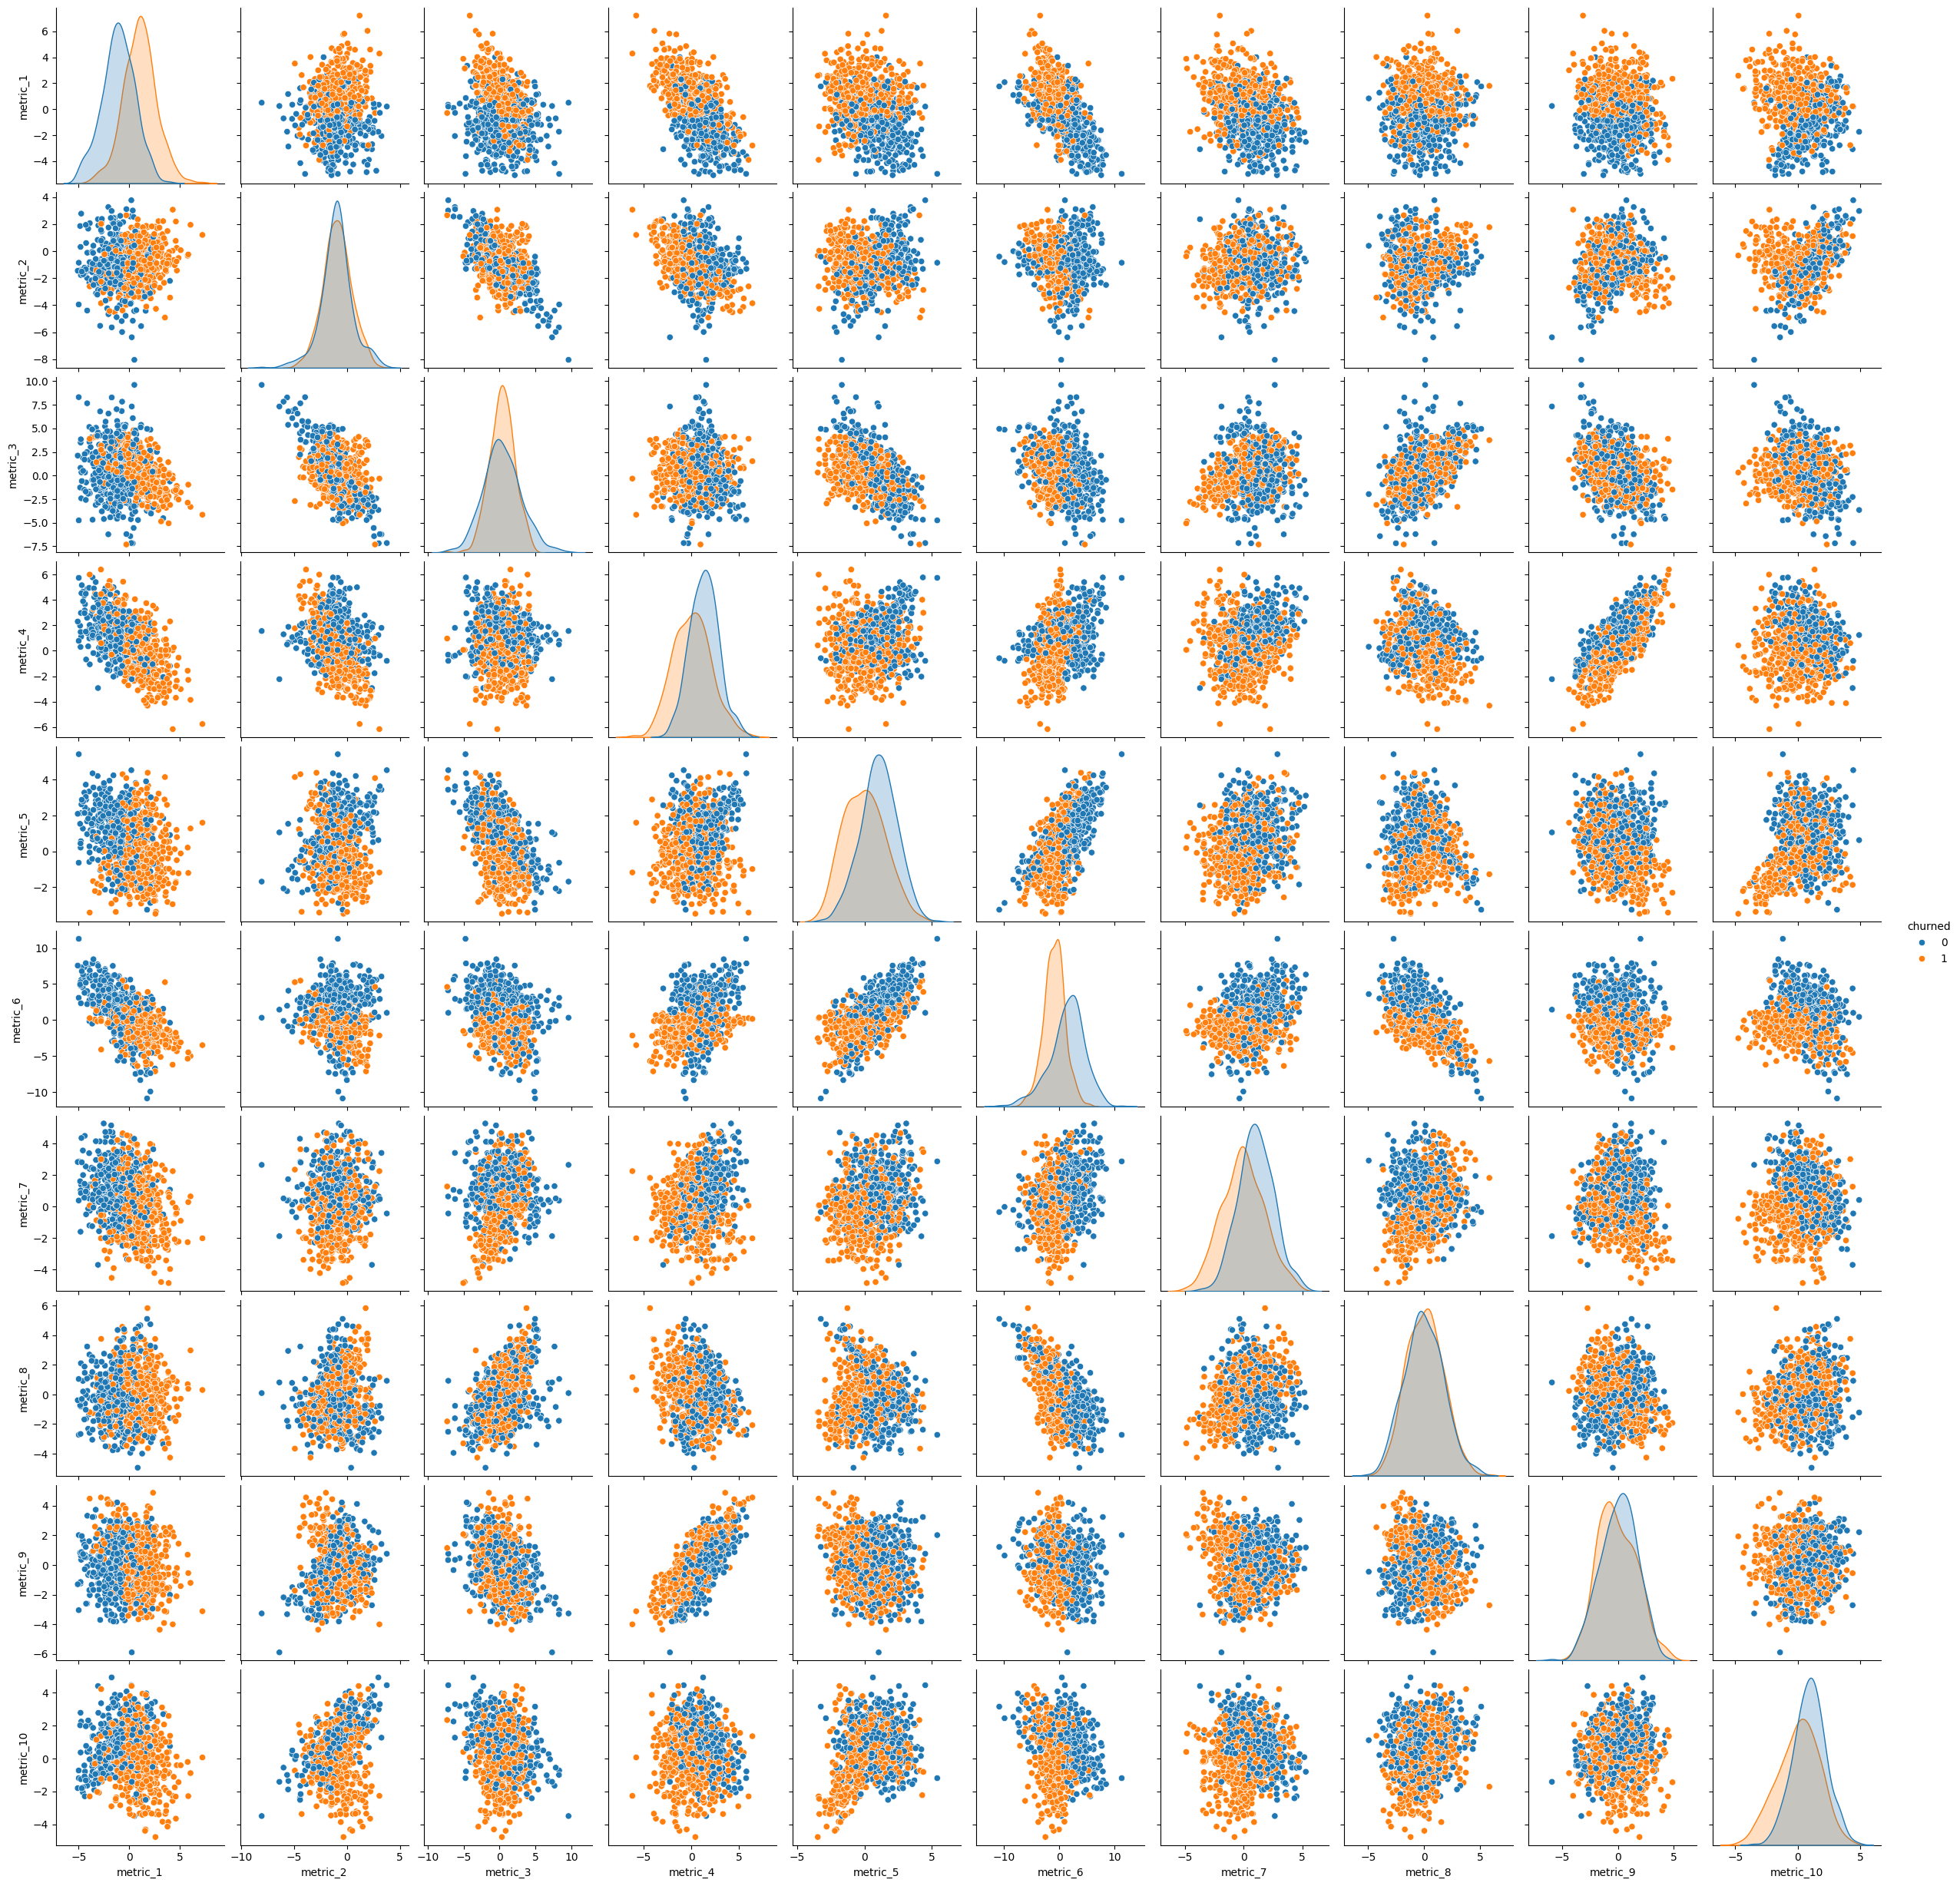

In [ ]:
sns.pairplot(df,hue='churned')

In [ ]:
df.columns

Index(['metric_1', 'metric_2', 'metric_3', 'metric_4', 'metric_5', 'metric_6',
       'metric_7', 'metric_8', 'metric_9', 'metric_10', 'churned'],
      dtype='object')

<Axes: xlabel='metric_1', ylabel='Density'>

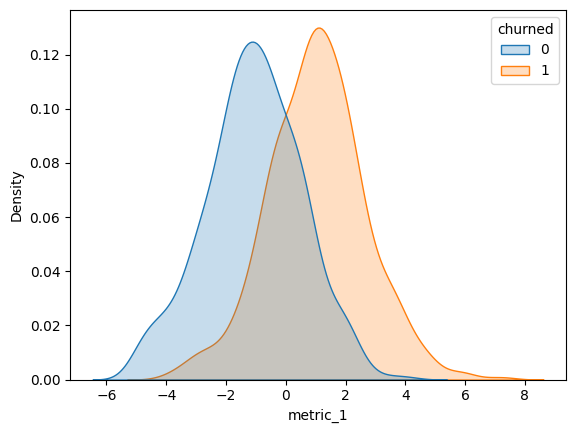

In [ ]:
sns.kdeplot(data=df,x='metric_1',fill=True,hue='churned')

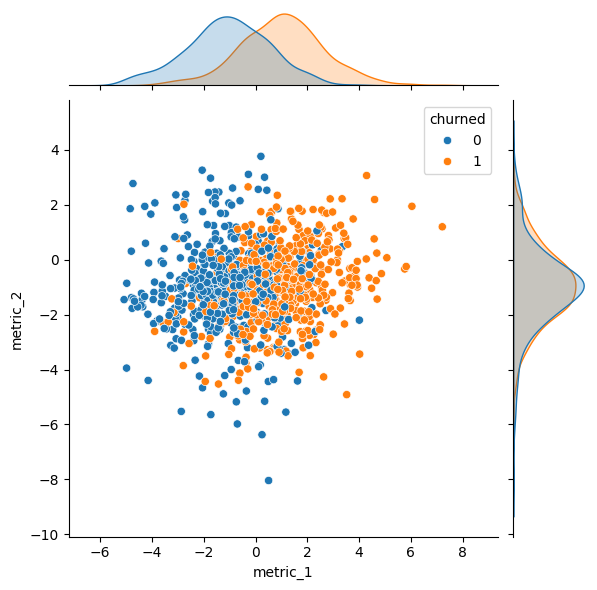

In [ ]:
sns.jointplot(data=df,x='metric_1',y='metric_2',hue='churned')

<Axes: xlabel='metric_1', ylabel='metric_2'>

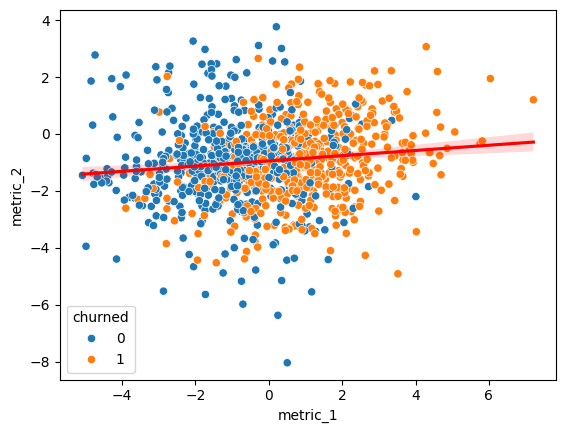

In [ ]:
sns.scatterplot(data=df,x='metric_1',y='metric_2',hue='churned')
sns.regplot(data=df,x='metric_1',y='metric_2',scatter=False,color='red')

<Axes: xlabel='churned', ylabel='metric_1'>

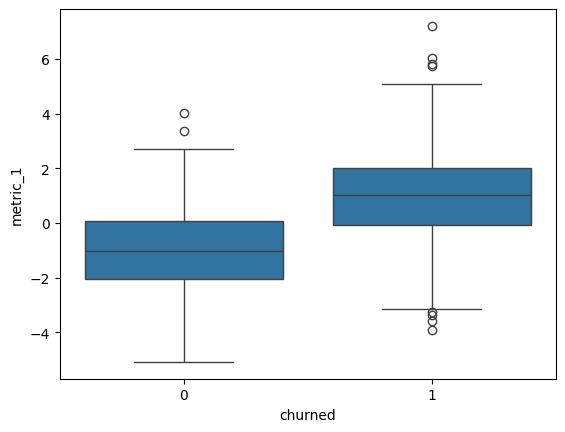

In [ ]:
sns.boxplot(data=df,x='churned',y='metric_1')

<Axes: xlabel='churned', ylabel='metric_1'>

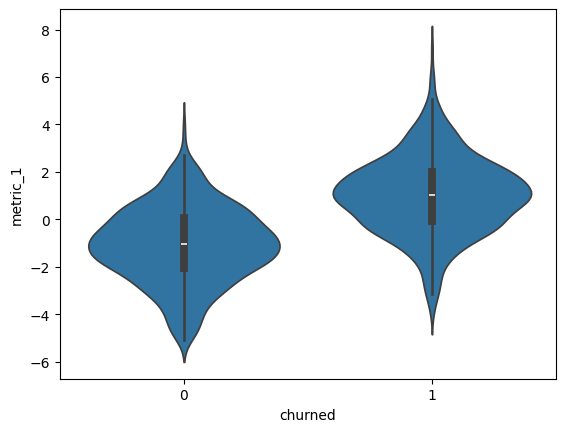

In [ ]:
sns.violinplot(data=df,x='churned',y='metric_1')

<Axes: xlabel='churned', ylabel='count'>

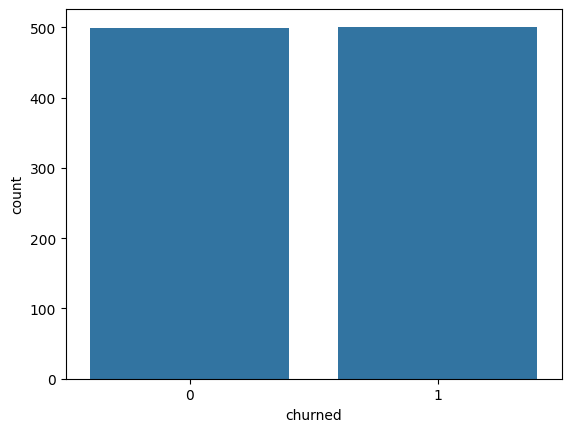

In [ ]:
sns.countplot(data=df,x='churned')

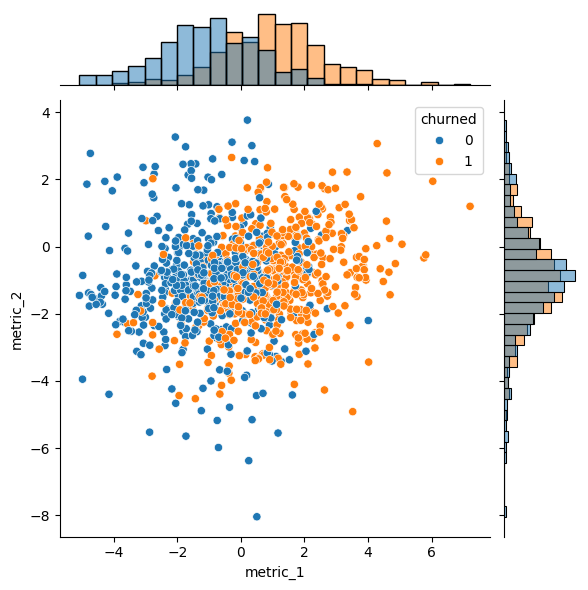

In [ ]:
sns.JointGrid(data=df,x='metric_1',y='metric_2',hue='churned').plot(sns.scatterplot,sns.histplot)


<Axes: xlabel='churned', ylabel='metric_1'>

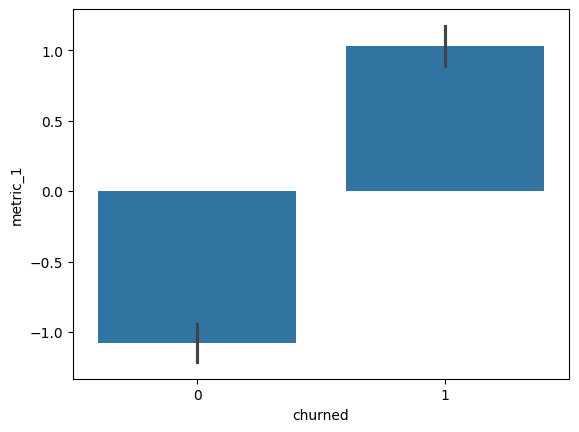

In [ ]:
sns.barplot(data=df,x='churned',y='metric_1')

<Axes: xlabel='churned', ylabel='metric_1'>

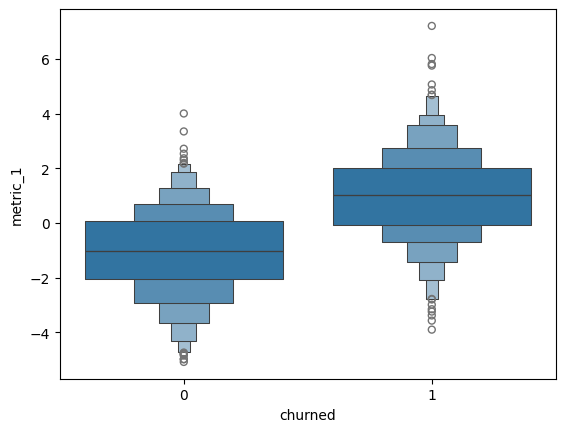

In [ ]:
sns.boxenplot(data=df,x='churned',y='metric_1')

<Axes: xlabel='churned', ylabel='metric_1'>

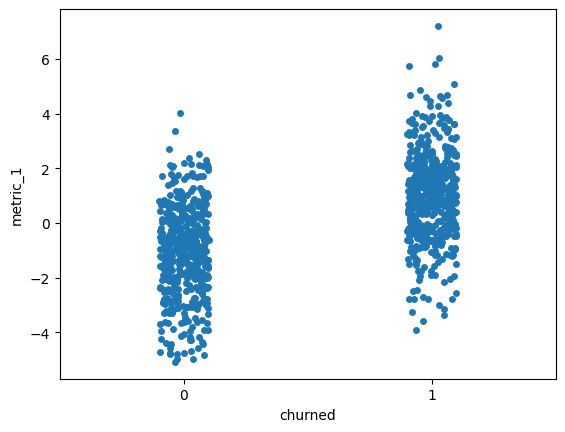

In [ ]:
sns.stripplot(data=df,x='churned',y='metric_1')

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 7.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 9.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


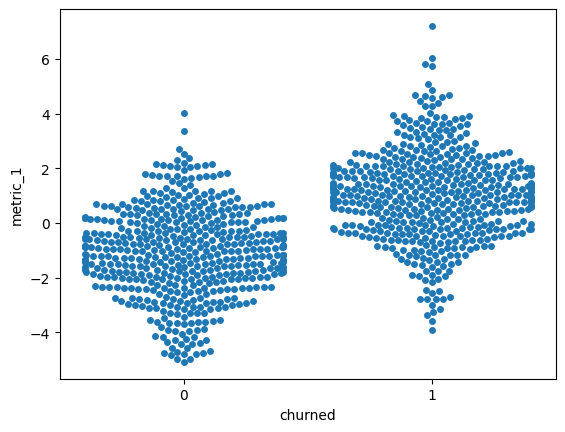

In [ ]:
sns.swarmplot(data=df,x='churned',y='metric_1')
plt.show()

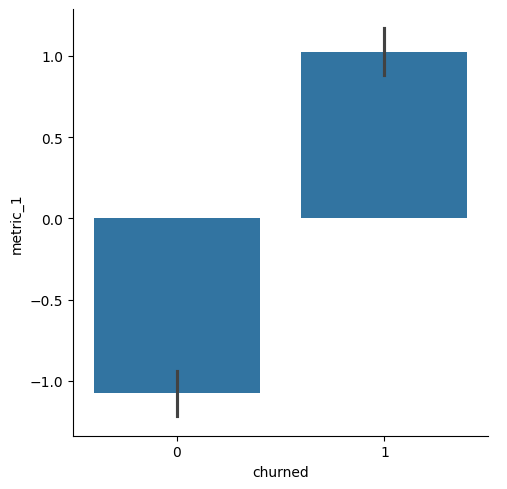

In [ ]:
sns.catplot(data=df,x='churned',y='metric_1',kind='bar')

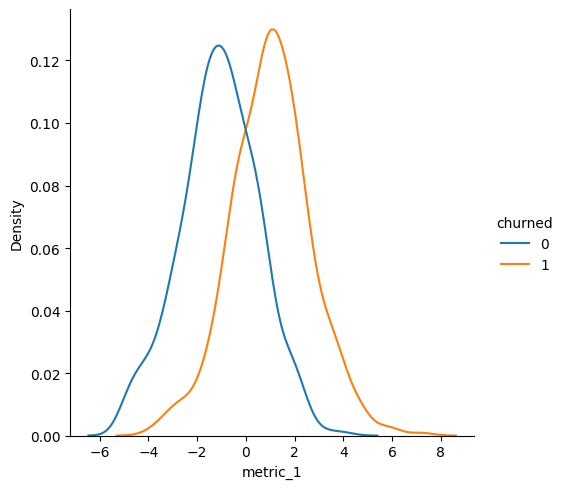

In [ ]:
sns.displot(data=df,x='metric_1',hue='churned',kind='kde')

In [ ]:
df['churned'].value_counts()

,count
churned,
1,501
0,499


In [ ]:
df.groupby('churned').mean()

,metric_1,metric_2,metric_3,metric_4,metric_5,metric_6,metric_7,metric_8,metric_9,metric_10
churned,,,,,,,,,,
0,-1.019780,-0.969865,0.370206,1.321288,1.046727,1.387113,1.046319,-0.023827,0.048432,0.944145
1,0.963092,-0.923748,0.323636,0.078298,-0.014199,-0.936147,-0.045038,0.060087,-0.074625,0.052083


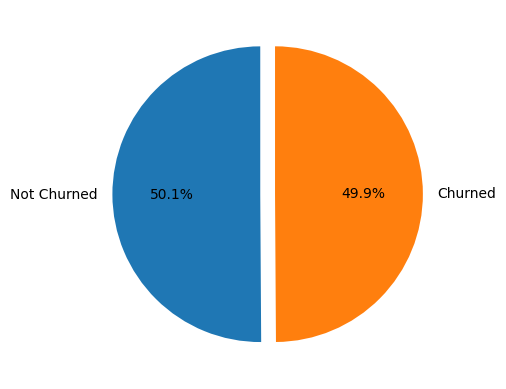

In [ ]:
plt.pie(df['churned'].value_counts(),labels=['Not Churned','Churned'],startangle=90,explode=(0,0.1,),autopct='%1.1f%%')
plt.show()

In [ ]:
# Introduce real-world imperfections (5% missing values randomly injected)
np.random.seed(42)
df.loc[np.random.rand(*df['metric_1'].shape) < 0.05, 'metric_1'] = np.nan
df.loc[np.random.rand(*df['metric_2'].shape) < 0.05, 'metric_2'] = np.nan

2. DATA CLEANING

In [ ]:
# Handle missing data using Median Imputation to resist outlier distortion
df['metric_1'] = df['metric_1'].fillna(df['metric_1'].median())
df['metric_2'] = df['metric_2'].fillna(df['metric_2'].median())

In [ ]:
df['metric_1'].value_counts()

,count
metric_1,
-0.017443,54
-0.347184,1
2.745792,1
-0.381642,1
2.633024,1
...,...
-2.905438,1
0.129724,1
0.152319,1


3. EXPLORATION & STANDARDIZATION

In [ ]:
# Separate features and target
X_raw = df[feature_names]
y_target = df['churned']

In [ ]:
X_raw

,metric_1,metric_2,metric_3,metric_4,metric_5,metric_6,metric_7,metric_8,metric_9,metric_10
0,-2.515984,-0.762055,-1.986676,4.148052,3.108808,6.324078,5.291429,-0.872057,1.183773,-0.805333
1,-0.672914,-1.563503,3.562810,0.396128,0.026731,-0.253737,3.483474,1.574252,-1.471795,0.698445
2,-1.953326,0.274618,0.050664,0.426035,1.272515,2.301115,1.280757,0.026285,-0.635284,1.614816
3,0.577318,-0.972563,0.355441,1.245819,-0.472508,-2.046506,-0.987116,0.734642,1.531011,-0.672260
4,-0.365302,-2.023199,0.731872,2.766902,-1.028713,-0.767302,-1.052613,-1.424615,2.164966,0.707496
...,...,...,...,...,...,...,...,...,...,...
995,1.468427,-0.715038,0.113270,-1.615633,0.476429,-1.802245,-2.027444,0.008016,-1.288974,2.388088
996,-0.137439,-0.901439,4.049779,-0.866080,-1.424819,-1.731930,2.718359,0.697166,-1.937974,2.316727
997,-2.499700,-0.709184,-4.605198,4.631038,3.802144,5.500652,0.085153,-1.794406,2.978009,0.615732
998,0.388159,-0.883744,3.308085,0.045588,-0.946480,-4.646834,1.058724,3.045642,0.004581,1.770809


In [ ]:
y_target

,churned
0,0
1,1
2,0
3,1
4,1
...,...
995,1
996,1
997,0
998,0


In [ ]:
# Standardize numerical ranges to mean=0 and variance=1 (Critical for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [ ]:
X_scaled

array([[-1.32757673,  0.13195643, -1.04776245, ..., -0.5313662 ,
         0.71207702, -0.83278467],
       [-0.34477038, -0.44061184,  1.44395303, ...,  0.92873555,
        -0.86768911,  0.12865107],
       [-1.02754257,  0.87257339, -0.13299811, ...,  0.00481756,
        -0.37005865,  0.71453015],
       ...,
       [-1.31889305,  0.16972858, -2.2234771 , ..., -1.08187886,
         1.77944634,  0.07576888],
       [ 0.22104057,  0.04501958,  1.32958167, ...,  1.80694823,
         0.01058974,  0.81426415],
       [-1.46553703, -0.93963062,  1.06919212, ..., -0.2652782 ,
         1.96466507, -1.10976195]])

4. DIMENSION REDUCTION

In [ ]:
# Instantiate PCA to retain 95% of the total cumulative variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print(pca.n_components_)

7


In [ ]:
print(X_pca.shape)

(1000, 7)


PIPELINE DIAGNOSTICS LOG

In [ ]:
print(f" Step 1 & 2: Missing values remaining: {df.isnull().sum().sum()}")
print(f" Step 3: Raw feature matrix dimensions: {X_scaled.shape}")
print(f" Step 4: Reduced feature matrix dimensions: {X_pca.shape}")
print(f"📊 Variance captured by the 7 components: {pca.explained_variance_ratio_}")
print(f"📈 Total variance retained: {sum(pca.explained_variance_ratio_):.4f}")

 Step 1 & 2: Missing values remaining: 0
 Step 3: Raw feature matrix dimensions: (1000, 10)
 Step 4: Reduced feature matrix dimensions: (1000, 7)
📊 Variance captured by the 7 components: [0.2736905  0.19301814 0.17562123 0.15178247 0.08659715 0.06751518
 0.04923225]
📈 Total variance retained: 0.9975


## Pipeline Breakdown & Explanations

### Data Cleaning & Handling Missing Values

Raw corporate datasets often contain missing or incomplete information. To identify these gaps, we check each column programmatically using `isnull().sum()`. For numerical columns with missing values, the **median** is used to fill the gaps. Median imputation is useful because it is less affected by extreme values or outliers than the mean. This helps maintain the overall structure of the dataset without allowing unusually large or small values to distort the results.

### Dimension Reduction Using PCA

High-dimensional datasets can contain many features that are related or provide overlapping information. This can make machine learning models more complex and less efficient. **Principal Component Analysis (PCA)** helps solve this problem by transforming the original 10 features into a smaller set of new variables called **principal components**.

By setting `n_components=0.95`, PCA automatically selects enough components to retain at least 95% of the variance in the original data. In this case, **7 components are retained**, while the remaining 3 dimensions are removed. This reduces the complexity of the dataset while still preserving most of the useful information needed for prediction.

---

## Algorithm Recommendation & Justification

To predict whether a customer will leave the company based on the processed PCA data, the recommended data-mining technique is a **Random Forest Classifier**.

### 1. Alignment with the Analytical Objective

The target variable, `churned`, has two possible outcomes: a customer either leaves or stays. This makes the problem a **supervised binary classification task**. Random Forest is well suited for this type of prediction because it can classify customers into the two categories based on patterns found in the available data.

### 2. Adaptability to the Dataset

* **Handles Non-Linear Relationships:** Customer behavior is not always straightforward. For example, a combination of reduced product usage and an increase in support requests may indicate a higher risk of churn. Random Forest can capture these complex relationships better than many simple linear models.

* **Reduces Overfitting:** A single decision tree can become too closely fitted to the training data. Random Forest reduces this problem by building many decision trees and combining their predictions. The final prediction is based on the collective decision of the trees, making the model more reliable.

* **Makes Few Distribution Assumptions:** Unlike methods that depend heavily on the statistical distribution or geometric distance between data points, Random Forest works by splitting observations according to feature values. This makes it suitable for data that may not follow a particular distribution, including data transformed through PCA.

Overall, **Random Forest is a strong choice for customer-churn prediction because it can handle complex patterns, reduce overfitting, and provide reliable classification results after dimensionality reduction.**
